# 🍎 Clasificación de Frutas con Redes Neuronales Convolucionales
## Universidad Tecnológica Nacional – Regional Rosario

> Notebook acotado a la **Etapa 2**: dataset realista *UTN-IA 2026 · Food Classification - Training Set*.


## Celda 0: Configuración del entorno

In [1]:
import torch

# Detectar dispositivo: CUDA (NVIDIA/Colab) > MPS (Apple Silicon) > CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Dispositivo: GPU NVIDIA – {torch.cuda.get_device_name(0)}')
    print(f'Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print('Dispositivo: Apple Silicon (MPS) – GPU Metal-accelerada')
else:
    device = torch.device('cpu')
    print('Dispositivo: CPU (no se detectó GPU)')

# Aprovechar todos los núcleos de CPU del M5 para ops que corren ahí
torch.set_num_threads(8)
print(f'Threads CPU: {torch.get_num_threads()}')


Dispositivo: Apple Silicon (MPS) – GPU Metal-accelerada
Threads CPU: 8


In [2]:
# Instalar dependencias adicionales
#!pip install -q kaggle scikit-learn seaborn

import os, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from utils import cargar_imagen_limpia
from dotenv import load_dotenv

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix

# Semilla para reproducibilidad
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)
elif torch.backends.mps.is_available(): torch.mps.manual_seed(SEED)

print(f'PyTorch {torch.__version__} | Torchvision {torchvision.__version__}')
print('✅ Librerías importadas')


PyTorch 2.13.0 | Torchvision 0.28.0
✅ Librerías importadas


---
# 🍓 ETAPA 2: Dataset UTN-IA 2026
## El desafío de generalización

Usamos el mismo modelo con un dataset con fondos variables e iluminación real.
El modelo obtendrá **peor desempeño**. Esta es la lección más importante:

> **El dataset determina tanto o más que la arquitectura.**

**Dataset:** UTN-IA 2026 · Food Classification - Training Set  
**Link:** https://www.kaggle.com/datasets/geronimoforconi/utn-ia-2026-food-classification-training-set  
**Licencia:** Apache 2.0

> ⚠️ Las imágenes tienen fondos variados e iluminación real: la distribución del dataset impacta fuertemente el rendimiento del modelo.


### Descarga del dataset

Para descargar desde Kaggle necesitás una API key:
1. Ir a kaggle.com → tu perfil → Settings → API → Create New Token
2. Copiar `API TOKEN`
3. Pegarlo en la celda de abajo


In [3]:
# Cargar credenciales desde .env (ignorado por git)
from dotenv import load_dotenv
load_dotenv()

os.environ.setdefault("KAGGLE_API_TOKEN", "")  # se setea vía load_dotenv
token = os.environ.get("KAGGLE_API_TOKEN")
if not token:
    raise RuntimeError("Falta KAGGLE_API_TOKEN en .env (ver .env.example)")
print("🔑 Token Kaggle cargado desde .env")


🔑 Token Kaggle cargado desde .env


In [4]:
!kaggle datasets download -d geronimoforconi/utn-ia-2026-food-classification-training-set \
    -p ./data/fruit_recognition --unzip -q
print("✅ Dataset UTN-IA 2026 descargado")

raiz_r = Path("./data/fruit_recognition")


Dataset URL: https://www.kaggle.com/datasets/geronimoforconi/utn-ia-2026-food-classification-training-set
License(s): apache-2.0
✅ Dataset UTN-IA 2026 descargado


### Hiperparámetros y transformación base (val/test)

In [5]:
IMG_SIZE   = 64
BATCH_SIZE = 128
NUM_CLASES = 5
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Pipeline base: val y test (sin augmentation)
transform_base = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

print('✅ Hiperparámetros + transform_base definidos (val/test)')
print('   Train usa un pipeline con augmentation (ver celda siguiente)')


✅ Hiperparámetros + transform_base definidos (val/test)
   Train usa un pipeline con augmentation (ver celda siguiente)


### Arquitectura de la CNN

In [6]:
class FrutasCNN(nn.Module):
    """
    CNN para clasificación de frutas.
    Cada bloque duplica filtros (32->64->128) y reduce tamaño espacial con MaxPool.
    """
    def __init__(self, num_classes=5):
        super().__init__()
        # Bloque 1: detecta bordes y texturas simples
        self.bloque1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 3 canales RGB -> 32 mapas
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 64x64 -> 32x32
        )
        # Bloque 2: detecta combinaciones de bordes
        self.bloque2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 32x32 -> 16x16
        )
        # Bloque 3: detecta representaciones complejas
        self.bloque3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 16x16 -> 8x8
        )
        # Clasificador final
        self.clasificador = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),   # Regularización contra overfitting
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.bloque1(x)
        x = self.bloque2(x)
        x = self.bloque3(x)
        return self.clasificador(x)


### Funciones de entrenamiento y evaluación

In [7]:
EPOCHS = 50
LR     = 1e-3

criterion = nn.CrossEntropyLoss()

def entrenar_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correcto, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        # AMP (mixed precision): acelera forward en MPS
        with torch.autocast(device_type=device.type if device.type in ('mps','cuda') else 'cpu'):
            out = model(imgs)
            loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        _, preds = out.max(1)
        total_loss += loss.item() * imgs.size(0)
        correcto   += preds.eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correcto / total

@torch.no_grad()
def evaluar(model, loader, criterion, device):
    model.eval()
    total_loss, correcto, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.autocast(device_type=device.type if device.type in ('mps','cuda') else 'cpu'):
            out = model(imgs)
            loss = criterion(out, labels)
        _, preds = out.max(1)
        total_loss += loss.item() * imgs.size(0)
        correcto   += preds.eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correcto / total


#### Helpers de visualización

In [8]:
def analizar_distribucion(base_dir):
    splits = ['train', 'val', 'test']
    conteos = {s: {} for s in splits}
    for s in splits:
        sd = base_dir / s
        if sd.exists():
            for c in os.listdir(sd):
                conteos[s][c] = len(list((sd/c).glob('*.jpg')))

    clases = list(conteos['train'].keys())
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(clases)); w = 0.25
    for idx, (s, col) in enumerate(zip(splits, ['#2196F3','#4CAF50','#FF9800'])):
        ax1.bar(x + idx*w, [conteos[s].get(c,0) for c in clases], w, label=s, color=col, alpha=0.85)
    ax1.set_xticks(x+w); ax1.set_xticklabels([c.split()[0] for c in clases], rotation=15)
    ax1.set_title('Distribución por clase y split'); ax1.legend(); ax1.grid(axis='y', alpha=0.3)

    totales = {c: sum(conteos[s].get(c,0) for s in splits) for c in clases}
    ax2.pie(totales.values(), labels=[c.split()[0] for c in clases], autopct='%1.1f%%', startangle=90)
    ax2.set_title('Distribución total')
    plt.tight_layout(); plt.show()

    print(f'{"Clase":<22} {"Train":>8} {"Val":>8} {"Test":>8}')
    print('-'*50)
    for c in clases:
        print(f'{c:<22} {conteos["train"].get(c,0):>8} {conteos["val"].get(c,0):>8} {conteos["test"].get(c,0):>8}')


In [9]:
def graficar_historial(hist, titulo='Etapa 2 – Food Classification'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ep = range(1, len(hist['train_loss'])+1)
    ax1.plot(ep, hist['train_loss'], 'b-o', ms=3, label='Train')
    ax1.plot(ep, hist['val_loss'],   'r-o', ms=3, label='Val')
    ax1.axvline(x=np.argmin(hist['val_loss'])+1, color='gray', ls='--', alpha=0.7)
    ax1.set_title('Curvas de Pérdida'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(ep, [a*100 for a in hist['train_acc']], 'b-o', ms=3, label='Train')
    ax2.plot(ep, [a*100 for a in hist['val_acc']],   'r-o', ms=3, label='Val')
    ax2.set_title('Curvas de Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylim([0,105])
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.suptitle(f'Historial de Entrenamiento – {titulo}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()
    print(f'Mejor Val Accuracy: {max(hist["val_acc"])*100:.2f}% (epoch {np.argmax(hist["val_acc"])+1})')


## Etapa 2: UTN-IA 2026 · Food Classification - Training Set

In [10]:
# ============================================================
# Etapa 2: UTN-IA 2026 · Food Classification - Training Set
# El dataset tiene solo imágenes de train → dividimos en train/val/test
# ============================================================
import shutil, random
from pathlib import Path

RAIZ_FOOD = Path('./data/fruit_recognition')
BASE_DIR_R = Path('./data/fruit_recognition_splint/')
CLASES_R   = ['apple', 'banana', 'grapes', 'potato', 'tomato']

# Proporciones del split (deben sumar 1.0)
SPLIT_TRAIN = 0.70
SPLIT_VAL   = 0.15
SPLIT_TEST  = 0.15

def crear_subset_desde_train(clases, raiz, destino, split_train=0.70, split_val=0.15):
    """
    Busca imágenes bajo raiz/<clase>/ o raiz/train/<clase>/,
    hace split estratificado y copia a destino/train|val|test/<clase>/.
    """
    # Detectar si las clases están directamente o bajo una subcarpeta 'train/'
    probe = raiz / clases[0]
    src_base = raiz if probe.exists() else raiz / 'train'

    for clase in clases:
        imgs = sorted([
            p for p in (src_base / clase).glob('**/*')
            if p.suffix.lower() in ('.jpg', '.jpeg', '.png')
        ])
        if not imgs:
            print(f'⚠️  Sin imágenes para clase "{clase}" en {src_base}')
            continue

        random.shuffle(imgs)
        n = len(imgs)
        n_val  = int(n * split_val)
        n_test = int(n * (1 - split_train - split_val))

        splits = {
            'val':   imgs[:n_val],
            'test':  imgs[n_val:n_val + n_test],
            'train': imgs[n_val + n_test:],
        }

        for split_name, subset in splits.items():
            dst = destino / split_name / clase
            dst.mkdir(parents=True, exist_ok=True)
            for img in subset:
                shutil.copy(img, dst / img.name)

        print(f'  {clase}: {len(splits["train"])} train | {len(splits["val"])} val | {len(splits["test"])} test')

    print(f'\n✅ Split creado en {destino}')

crear_subset_desde_train(CLASES_R, RAIZ_FOOD, BASE_DIR_R, SPLIT_TRAIN, SPLIT_VAL)

  apple: 39 train | 7 val | 7 test
  banana: 42 train | 9 val | 9 test
  grapes: 56 train | 11 val | 11 test
  potato: 44 train | 9 val | 9 test
  tomato: 52 train | 10 val | 10 test

✅ Split creado en data/fruit_recognition_splint


## Clases seleccionadas para clasificar


✅ Subset realista creado


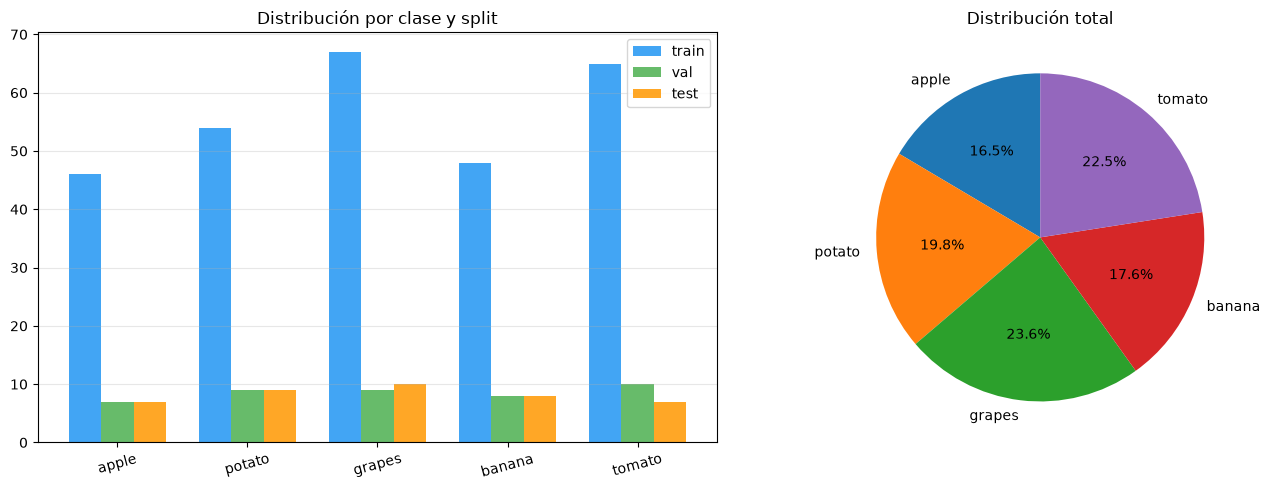

Clase                     Train      Val     Test
--------------------------------------------------
apple                        46        7        7
potato                       54        9        9
grapes                       67        9       10
banana                       48        8        8
tomato                       65       10        7


In [11]:
for split, split_src_name in [('train','train'), ('val','validation'), ('test','test')]:
    src_base = raiz_r / split_src_name
    if not src_base.exists(): continue
    for clase in CLASES_R:
        src = src_base / clase
        if src.exists():
            dst = BASE_DIR_R / split / clase
            dst.mkdir(parents=True, exist_ok=True)
            for img in src.glob('*.*'):
                if img.suffix.lower() in ['.jpg','.jpeg','.png']:
                    shutil.copy(img, dst / img.name)

print('✅ Subset realista creado')
analizar_distribucion(BASE_DIR_R)


## Visualización de ejemplos del dataset realista

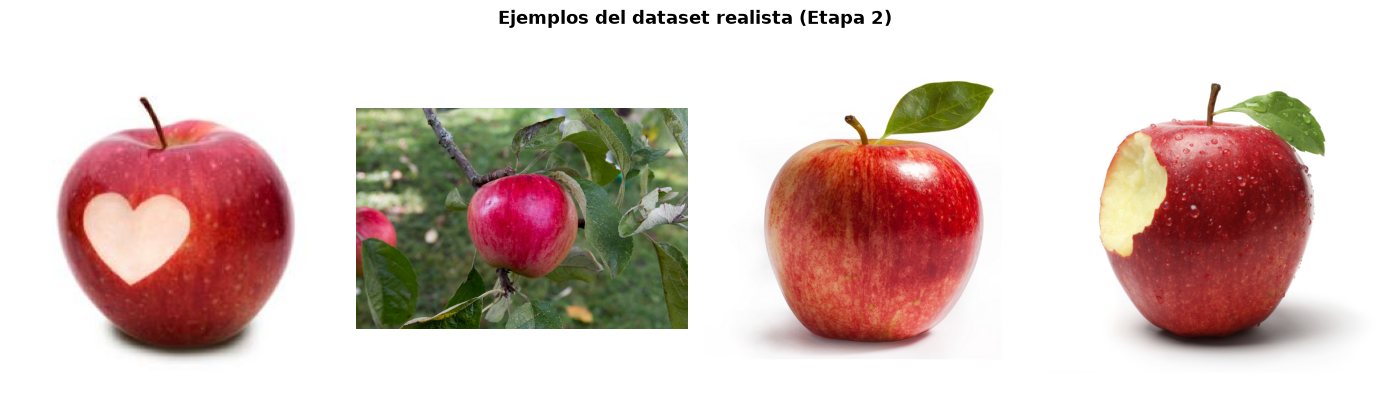

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
base = BASE_DIR_R
clase = CLASES_R[0]
carpeta = base / 'train' / clase
imgs = list(carpeta.glob('*.jpg'))[:4] or list(carpeta.glob('*.png'))[:4]
for col, img_path in enumerate(imgs[:4]):
    axes[col].imshow(Image.open(img_path))
    axes[col].axis('off')
    if col == 0:
        axes[col].set_ylabel('Dataset Realista', fontsize=10, fontweight='bold')
plt.suptitle('Ejemplos del dataset realista (Etapa 2)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## Augmentation

In [13]:
# Augmentation más agresivo para el dataset realista (pocos datos, más variabilidad)
transform_train_r = transforms.Compose([
    transforms.Resize((IMG_SIZE+16, IMG_SIZE+16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.2),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

train_r = ImageFolder(str(BASE_DIR_R/'train'), transform=transform_train_r,
                      loader=cargar_imagen_limpia)
val_r   = ImageFolder(str(BASE_DIR_R/'val'),   transform=transform_base,
                      loader=cargar_imagen_limpia)
test_r  = ImageFolder(str(BASE_DIR_R/'test'),  transform=transform_base,
                      loader=cargar_imagen_limpia)

train_loader_r = DataLoader(train_r, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=6, persistent_workers=True, prefetch_factor=4, pin_memory=False)
val_loader_r   = DataLoader(val_r,   batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=4, persistent_workers=True, prefetch_factor=4, pin_memory=False)
test_loader_r  = DataLoader(test_r,  batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=4, persistent_workers=True, prefetch_factor=4, pin_memory=False)

class_names_r = train_r.classes
print(f'✅ Dataset realista: train={len(train_r)} | val={len(val_r)} | test={len(test_r)}')


✅ Dataset realista: train=325 | val=46 | test=46


## Entrenar el MISMO modelo en el dataset realista


In [14]:
# Asegurar directorios locales necesarios
Path('./data').mkdir(parents=True, exist_ok=True)
Path('./checkpoints').mkdir(parents=True, exist_ok=True)
print('✅ Directorios data/ y checkpoints/ listos')


✅ Directorios data/ y checkpoints/ listos


In [ ]:
modelo_r = FrutasCNN(num_classes=len(class_names_r)).to(device)
optimizer_r = optim.Adam(modelo_r.parameters(), lr=1e-3, weight_decay=1e-3)  # mayor regularización
scheduler_r = optim.lr_scheduler.ReduceLROnPlateau(optimizer_r, patience=5, factor=0.5)

historial_r = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
mejor_r = float('inf'); CKPT_R = './checkpoints/mejor_modelo_realista.pth'

print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>10} | {"Val Loss":>10} | {"Val Acc":>10}')
print('-'*58)

for epoch in range(1, EPOCHS+1):
    tl, ta = entrenar_epoch(modelo_r, train_loader_r, criterion, optimizer_r, device)
    vl, va = evaluar(modelo_r, val_loader_r, criterion, device)
    scheduler_r.step(vl)
    for k, v in [('train_loss',tl),('val_loss',vl),('train_acc',ta),('val_acc',va)]:
        historial_r[k].append(v)
    marca = ''
    if vl < mejor_r:
        mejor_r = vl
        torch.save({'epoch':epoch, 'model_state_dict':modelo_r.state_dict(), 'val_acc':va}, CKPT_R)
        marca = ' ✅'
    print(f'{epoch:>6} | {tl:>10.4f} | {ta:>9.1%} | {vl:>10.4f} | {va:>9.1%}{marca}')


 Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc
----------------------------------------------------------
     1 |     2.9991 |     24.3% |     1.5388 |     34.8% ✅
     2 |     3.5296 |     36.9% |     1.3086 |     47.8% ✅
     3 |     1.8723 |     42.5% |     1.2612 |     43.5% ✅
     4 |     1.5534 |     36.3% |     1.2120 |     47.8% ✅
     5 |     1.3656 |     41.5% |     1.2317 |     54.3%
     6 |     1.3025 |     49.2% |     1.2453 |     65.2%
     7 |     1.3317 |     45.8% |     1.2338 |     67.4%
     8 |     1.3012 |     49.2% |     1.1701 |     67.4% ✅
     9 |     1.2950 |     49.5% |     1.1124 |     58.7% ✅
    10 |     1.2653 |     48.9% |     1.1043 |     60.9% ✅
    11 |     1.2820 |     47.1% |     1.0969 |     60.9% ✅
    12 |     1.2423 |     50.5% |     1.1028 |     60.9%
    13 |     1.2299 |     50.5% |     1.1130 |     63.0%
    14 |     1.2235 |     47.7% |     1.1120 |     65.2%
    15 |     1.2103 |     48.9% |     1.0871 |     71.7% ✅
    16 | 

## Curvas de aprendizaje (Etapa 2)

In [ ]:
graficar_historial(historial_r, titulo='Etapa 2 – Food Classification')
